In [4]:
import pandas as pd
import numpy as np

In [5]:
billings = pd.read_csv('../../data/cleaned/billings_cleaned.csv', low_memory=False)

##  Feature Engineering

### Binary Churn Target

In [6]:
billings['churn'] = (billings['Prospect_Outcome'] == 'Churned').astype(int)

print('Churn distribution:')
print(billings['churn'].value_counts())
print(f'\nChurn rate: {billings["churn"].mean()*100:.2f}%')

Churn distribution:
churn
0    101223
1     12608
Name: count, dtype: int64

Churn rate: 11.08%


### Price Increase Features

In [7]:
# price_increase_pct: year-on-year % change
# Guard: only compute where Last_Years_Price > 0 (avoid div-by-zero)
billings['price_increase_pct'] = np.where(
    billings['Last_Years_Price'] > 0,
    ((billings['Amount'] - billings['Last_Years_Price']) / billings['Last_Years_Price'] * 100).round(2),
    0.0  # New customers: no prior price, no increase
)

# price_increased: binary flag
billings['price_increased'] = (billings['price_increase_pct'] > 0).astype(int)

print('price_increase_pct stats:')
print(billings['price_increase_pct'].describe().round(2))
print(f'\nRows with price increase: {billings["price_increased"].sum():,} ({billings["price_increased"].mean()*100:.1f}%)')
print(f'Rows with no change / decrease: {(~billings["price_increased"].astype(bool)).sum():,}')

# Sanity check: no inf or NaN
print(f'\nInf values in price_increase_pct: {np.isinf(billings["price_increase_pct"]).sum()}')
print(f'NaN values in price_increase_pct: {billings["price_increase_pct"].isnull().sum()}')

price_increase_pct stats:
count    113831.00
mean         37.42
std         382.58
min        -100.00
25%           0.00
50%           0.00
75%           0.00
max       22039.39
Name: price_increase_pct, dtype: float64

Rows with price increase: 21,137 (18.6%)
Rows with no change / decrease: 92,694

Inf values in price_increase_pct: 0
NaN values in price_increase_pct: 0


###  Band Ordinal Encoding

In [8]:
BAND_ORDER = {
    'Band A' : 1,  'Band B' : 2,  'Band C1': 3,  'Band C2': 4,
    'Band D' : 5,  'Band E' : 6,  'Band F' : 7,  'Band F1': 8,
    'Band F2': 9,  'Band G' : 10, 'Band H' : 11, 'Band I' : 12,
    'Band J' : 13, 'Group'  : 14
}

billings['band_ordinal'] = billings['Band'].map(BAND_ORDER)
billings['last_band_ordinal'] = billings['Last_Band'].map(BAND_ORDER)  # NaN for 'New Customer'

# band_change: positive = upgraded tier, negative = downgraded, 0 = same or new
billings['band_change'] = (
    billings['band_ordinal'] - billings['last_band_ordinal']
).fillna(0)  # 0 for new customers — no prior band to compare

print('band_change null count:', billings['band_change'].isnull().sum())


band_change null count: 0


### Tenure Features

In [9]:
# is_first_renewal: 1 if Tenure_Years <= 1 (highest churn risk cohort)
billings['is_first_renewal'] = (billings['Tenure_Years'] <= 1).astype(int)

print('is_first_renewal distribution:')
print(billings['is_first_renewal'].value_counts())
print(f'\nFirst-renewal churn rate : {billings[billings["is_first_renewal"]==1]["churn"].mean()*100:.1f}%')
print(f'Returning customer churn : {billings[billings["is_first_renewal"]==0]["churn"].mean()*100:.1f}%')

is_first_renewal distribution:
is_first_renewal
0    95810
1    18021
Name: count, dtype: int64

First-renewal churn rate : 21.8%


Returning customer churn : 9.1%


### Discount Applied Flag

In [10]:
# discount_applied: 1 if customer paid less than the full asking Amount
billings['discount_applied'] = (billings['Total_Net_Paid'] < billings['Amount']).astype(int)

print('discount_applied distribution:')
print(billings['discount_applied'].value_counts())
print(f'\n% customers who received a discount: {billings["discount_applied"].mean()*100:.1f}%')

discount_applied distribution:
discount_applied
0    97738
1    16093
Name: count, dtype: int64

% customers who received a discount: 14.1%


### Payment Method: Standardise & Encode Unknown

In [11]:
print('Payment_Method raw distribution:')
print(billings['Payment_Method'].value_counts())

# Flag unknown payment method separately — it's a signal in itself
billings['payment_method_unknown'] = (billings['Payment_Method'] == 'UNKNOWN').astype(int)

print(f'\npayment_method_unknown: {billings["payment_method_unknown"].sum():,} rows ({billings["payment_method_unknown"].mean()*100:.1f}%)')

Payment_Method raw distribution:
Payment_Method
CARD         71071
BACS         33190
UNKNOWN       7800
WORLD PAY     1699
CHEQUE          71
Name: count, dtype: int64

payment_method_unknown: 7,800 rows (6.9%)


In [12]:
billings.columns

Index(['Co_Ref', 'Renewal_Month', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Current_Anchorings', 'Payment_Timeframe', 'Registration_Date',
       'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band',
       'Prospect_Renewal_Date', 'Closed_Date', 'Prospect_Status',
       'Total_Net_Paid', 'Prospect_Outcome', 'Payment_Method', 'Amount',
       'Connection_Group', 'Tenure_Group', '#_of_Connection', 'Last_Band',
       'Last_Connections', 'Renewal_Year', 'auto_renewal',
       'has_worldpay_token', 'days_as_member', 'churn', 'price_increase_pct',
       'price_increased', 'band_ordinal', 'last_band_ordinal', 'band_change',
       'is_first_renewal', 'discount_applied', 'payment_method

In [13]:
billings.shape

(113831, 46)

In [14]:
billings['churn'].head(5)

0    0
1    0
2    0
3    0
4    0
Name: churn, dtype: int64

In [15]:
billings.info()

<class 'pandas.DataFrame'>
RangeIndex: 113831 entries, 0 to 113830
Data columns (total 46 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Co_Ref                      113831 non-null  str    
 1   Renewal_Month               113831 non-null  str    
 2   Sustainability_Score        113831 non-null  float64
 3   Total_Renewal_Score_New     113831 non-null  float64
 4   Last_Years_Price            113831 non-null  float64
 5   Auto_Renewal_Score          113831 non-null  int64  
 6   Status_Scores               113831 non-null  int64  
 7   Anchoring_Score             113831 non-null  float64
 8   Tenure_Scores               113831 non-null  float64
 9   Current_Anchorings          113831 non-null  int64  
 10  Payment_Timeframe           113831 non-null  float64
 11  Registration_Date           113831 non-null  str    
 12  Proforma_Account_Stage      104669 non-null  str    
 13  Proforma_Audit_Status    

## Final Column Selection
Select only the columns we will use for modelling.

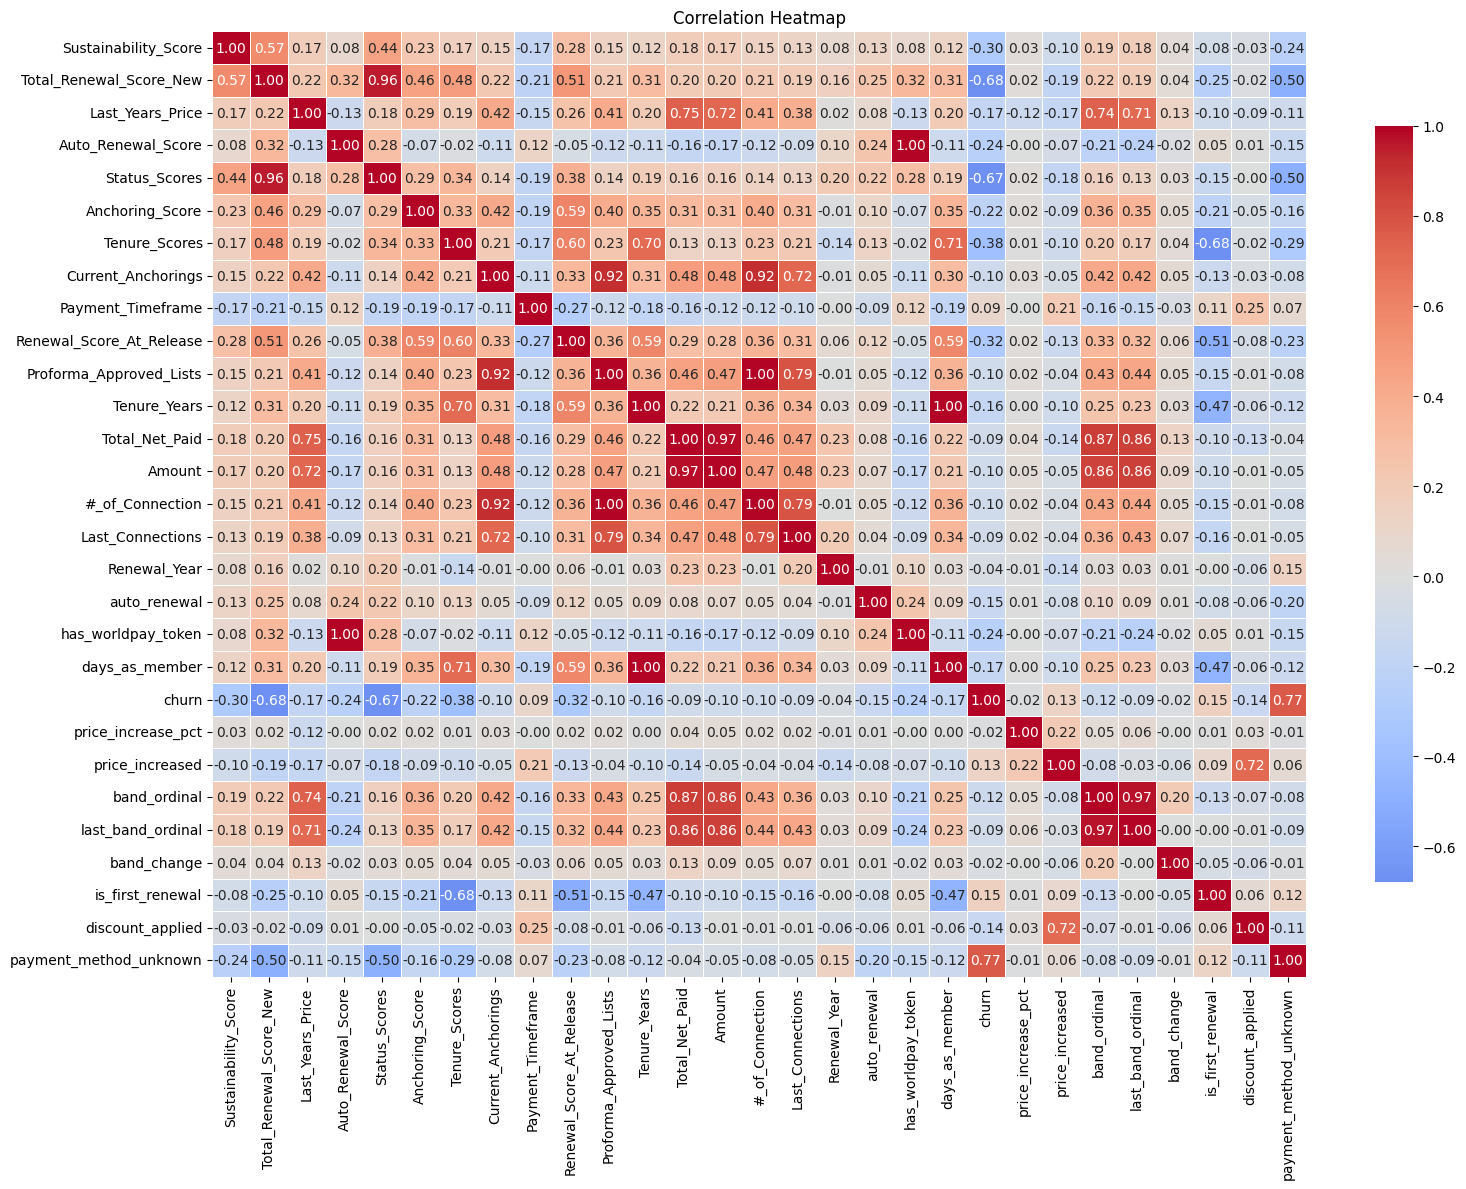

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Only numeric columns
corr = billings.select_dtypes(include=['number']).corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr,     
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
FINAL_COLS = [
    # ── Identity & Time ─────────────────────────────────────
    'Co_Ref',
    'Renewal_Year',
    'Prospect_Renewal_Date',
    'Registration_Date',

    # ── Target ──────────────────────────────────────────────
    'churn',

    # ── Membership Tier ─────────────────────────────────────
    'band_ordinal',
    'last_band_ordinal',
    'band_change',

    # ── Tenure ──────────────────────────────────────────────
    'Tenure_Years',
    'Tenure_Group',
    'is_first_renewal',

    # ── Auto-Renewal & Payment ───────────────────────────────
    'auto_renewal',
    'Payment_Method',
    'payment_method_unknown',
    'discount_applied',

    # ── Pricing ──────────────────────────────────────────────
    'Last_Years_Price',
    'price_increase_pct',

    # ── Renewal Scores ───────────────────────────────────────
    'Total_Renewal_Score_New',
    'Renewal_Score_At_Release',
    'Auto_Renewal_Score',
    'Anchoring_Score',
    'Tenure_Scores',
    'Sustainability_Score',

    # ── Client Connections ──────────────────────────────────
    'Connection_Group',
    'Current_Anchorings',

    # ── Accreditation / Membership ──────────────────────────
    'Proforma_Account_Stage',
    'Proforma_Membership_Status'
]

# Keep only columns that exist in df
FINAL_COLS = [c for c in FINAL_COLS if c in billings.columns]

df_clean = billings[FINAL_COLS].copy()

print(f'Final clean shape: {df_clean.shape}')
print(f'\nFinal columns ({len(df_clean.columns)}):')
for i, c in enumerate(df_clean.columns, 1):
    print(f'  {i:2}. {c}  [{df_clean[c].dtype}]')

Final clean shape: (113831, 28)

Final columns (28):
   1. Co_Ref  [str]
   2. Renewal_Year  [int64]
   3. Prospect_Renewal_Date  [str]
   4. Registration_Date  [str]
   5. churn  [int64]
   6. band_ordinal  [float64]
   7. last_band_ordinal  [float64]
   8. band_change  [float64]
   9. Tenure_Years  [float64]
  10. Tenure_Group  [str]
  11. is_first_renewal  [int64]
  12. auto_renewal  [int64]
  13. Payment_Method  [str]
  14. payment_method_unknown  [int64]
  15. discount_applied  [int64]
  16. Amount  [int64]
  17. Last_Years_Price  [float64]
  18. price_increase_pct  [float64]
  19. Total_Renewal_Score_New  [float64]
  20. Renewal_Score_At_Release  [float64]
  21. Auto_Renewal_Score  [int64]
  22. Anchoring_Score  [float64]
  23. Tenure_Scores  [float64]
  24. Sustainability_Score  [float64]
  25. Connection_Group  [str]
  26. Current_Anchorings  [int64]
  27. Proforma_Account_Stage  [str]
  28. Proforma_Membership_Status  [str]


In [18]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[^a-z0-9_]', '_', regex=True)
    )
    return df

df_clean = clean_columns(df_clean)

In [19]:
df_clean.head()

,co_ref,renewal_year,prospect_renewal_date,registration_date,churn,band_ordinal,last_band_ordinal,band_change,tenure_years,tenure_group,...,total_renewal_score_new,renewal_score_at_release,auto_renewal_score,anchoring_score,tenure_scores,sustainability_score,connection_group,current_anchorings,proforma_account_stage,proforma_membership_status
0,VT6174,2024,2024-11-05,2021-11-05 00:00:00,0,3.0,2.0,1.0,3.0,3,...,42.5,26.0,9,7.5,9.0,8.0,1,0,Published,Accredited
1,VD3828,2025,2025-08-09,2024-08-09 00:00:00,0,3.0,NaN,0.0,1.0,1,...,41.5,24.5,9,7.5,8.0,8.0,1,0,Published,Accredited
2,DV8120,2025,2025-03-12,2015-03-12 00:00:00,0,3.0,3.0,0.0,10.0,4+,...,33.0,24.0,8,7.5,9.5,8.0,1,0,Membership Only,Member Only
3,EZ9894,2025,2025-06-29,2014-06-27 00:00:00,0,3.0,3.0,0.0,11.0,4+,...,44.5,27.0,9,7.5,9.5,9.5,1,0,Renewal Process,Accredited
4,FA8957,2025,2025-03-25,2022-03-25 00:00:00,0,3.0,3.0,0.0,3.0,3,...,42.5,26.0,9,7.5,8.5,9.5,1,0,Published,Accredited
